# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file)

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table.
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
student_data = pd.DataFrame({
    'Age': [17, 51, 27, 21, 36, 48, 19, 26, 54, 30],
    'Tardies': [10, 1, 5, 9, 4, 2, 9, 6, 0, 3]
})

Draw a dispersion diagram (scatter plot) for the data.

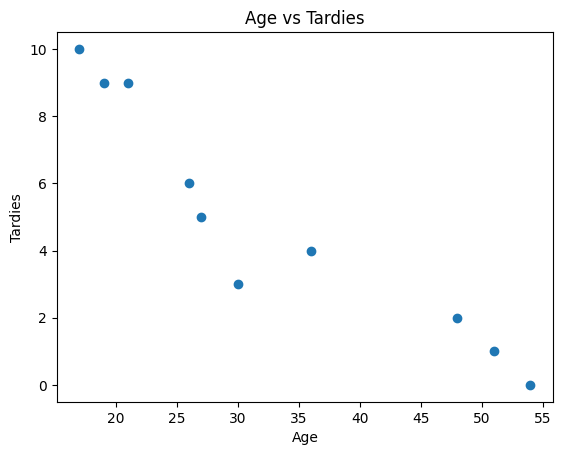

In [3]:
plt.scatter(student_data['Age'], student_data['Tardies'])
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Age vs Tardies')
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

negative relationship between age and tardies

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [7]:
# Calculate covariance
covariance = student_data.cov()

correlation = student_data.corr()

print("Covariance:\n", covariance)
print("\nCorrelation:\n", correlation)


Covariance:
                 Age    Tardies
Age      187.655556 -45.566667
Tardies  -45.566667  12.544444

Correlation:
               Age   Tardies
Age      1.000000 -0.939163
Tardies -0.939163  1.000000


In [ ]:
# Covariance:
# Covariance measures how two variables change together.
# A negative covariance means that as one variable increases,
# the other decreases.

# Correlation:
# Correlation is a standardized version of covariance.
# It ranges from -1 to 1, making it easier to interpret.
# -1 = perfect negative relationship
#  0 = no relationship
#  1 = perfect positive relationship

# Difference:
# - Covariance depends on the scale of the data (not standardized).
# - Correlation is normalized, so it is easier to compare and interpret.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [8]:
# Define independent (X) and dependent (y) variables
X = student_data[['Age']]
y = student_data['Tardies']

# Create and fit the regression model
model = LinearRegression()
model.fit(X, y)

# Get model parameters
slope = model.coef_[0]
intercept = model.intercept_

print("Slope (coefficient):", slope)
print("Intercept:", intercept)

# Make predictions (optional)
predictions = model.predict(X)
print("Predictions:", predictions)

Slope (coefficient): -0.2428207709159809
Intercept: 12.888803363135771
Predictions: [ 8.76085026  0.50494405  6.33264255  7.78956717  4.14725561  1.23340636
  8.27520872  6.57546332 -0.22351827  5.60418024]


In [ ]:
# Conclusion:
# As age increases, tardiness decreases.
# This supports the hypothesis that younger students tend to be late more often.

Plot your regression model on your scatter plot.

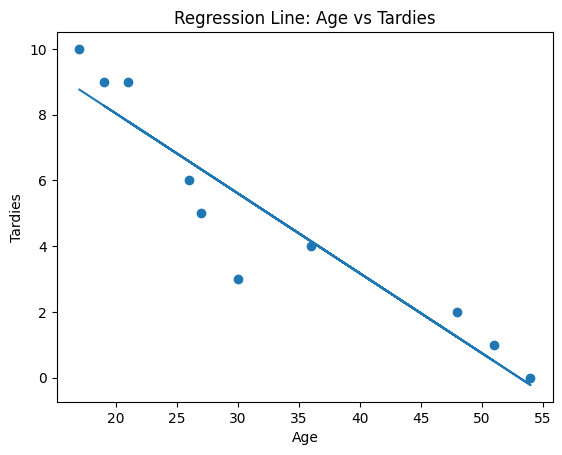

In [9]:
# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions for regression line
y_pred = model.predict(X)

# Plot scatter
plt.scatter(X, y)

# Plot regression line
plt.plot(X, y_pred)

# Labels and title
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Regression Line: Age vs Tardies')

# Show plot
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

Is age a good predictor?
- Age is a useful predictor of tardiness in this dataset,
- as it shows a consistent relationship.
- However, it is likely not the only factor affecting tardiness.
- Therefore, age is a moderately good predictor, but not a perfect one.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables.

In [12]:
# Import any libraries you may need & the data
df = pd.read_csv("https://raw.githubusercontent.com/Dee-M123/lab-regression-analysis-en/refs/heads/main/vehicles.csv")

df.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable.

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [13]:
# Select relevant variables
cols = [
    'Year',
    'Cylinders',
    'Fuel Barrels/Year',
    'Combined MPG',
    'Fuel Cost/Year',
    'CO2 Emission Grams/Mile'
]

data = df[cols]

# Compute correlation matrix
corr_matrix = data.corr()

print(corr_matrix)

# Correlation with target variable
co2_corr = corr_matrix['CO2 Emission Grams/Mile'].sort_values(ascending=False)
print("\nCorrelation with CO2 Emissions:\n", co2_corr)

                             Year  Cylinders  Fuel Barrels/Year  Combined MPG  \
Year                     1.000000   0.082469          -0.221084      0.204751   
Cylinders                0.082469   1.000000           0.739517     -0.698648   
Fuel Barrels/Year       -0.221084   0.739517           1.000000     -0.909743   
Combined MPG             0.204751  -0.698648          -0.909743      1.000000   
Fuel Cost/Year          -0.091913   0.778153           0.916208     -0.875185   
CO2 Emission Grams/Mile -0.222300   0.752393           0.986189     -0.926229   

                         Fuel Cost/Year  CO2 Emission Grams/Mile  
Year                          -0.091913                -0.222300  
Cylinders                      0.778153                 0.752393  
Fuel Barrels/Year              0.916208                 0.986189  
Combined MPG                  -0.875185                -0.926229  
Fuel Cost/Year                 1.000000                 0.930865  
CO2 Emission Grams/Mile       

In [ ]:
# Variables directly related to fuel consumption (Fuel Barrels/Year and MPG)
# are the best predictors of CO2 emissions.

# Final takeaway:
# Fuel usage is the dominant factor in determining CO2 emissions,
# while general characteristics like year have much less predictive power.

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [14]:
X = df[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']]

# Define dependent variable (target)
y = df['CO2 Emission Grams/Mile']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Print coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-0.32061673  1.87879976 19.05292507 -3.04039938  0.03230948]
Intercept: 769.8882836465673


In [ ]:
# - The model confirms that fuel consumption is the strongest driver of CO2 emissions.
# - Fuel efficiency (MPG) significantly reduces emissions.
# - Engine size (cylinders) also contributes to higher emissions.
# - Year has only a minor effect.

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [16]:
import statsmodels.api as sm
X = vehicles[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']]
y = vehicles['CO2 Emission Grams/Mile']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                             13:51:19   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended.

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression.
First, build a dataframe with the data.

In [ ]:
# Your code here.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [ ]:
# Your code here.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model.

In [ ]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*